# Students Performance In Exams - Kaggle

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [3]:
df = pd.read_csv(r"C:\Users\gs602\OneDrive\Documents\Students Performance In Exams - Kaggle\StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Data Cleaning

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace = True)

# Feature Engineering

In [10]:
df["average score"] = df["math score"] + df["reading score"] + df["writing score"] / 3

In [12]:
df["result"] = df["average score"].apply(lambda x: 1 if x >= 40 else 0)

# Data Visualization

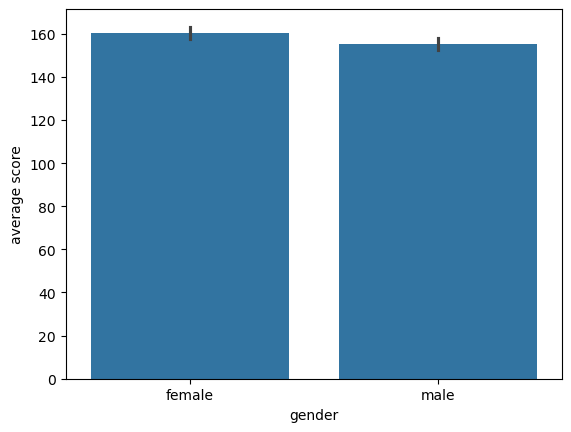

In [13]:
sns.barplot(x="gender" , y="average score" , data=df)
plt.show()

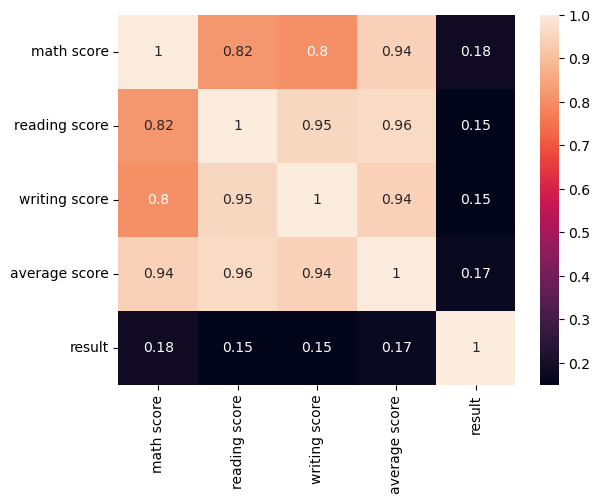

In [14]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)
plt.show()

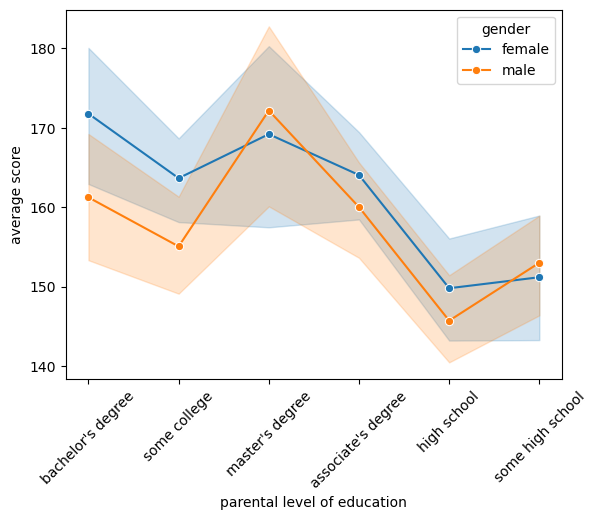

In [23]:


sns.lineplot(
    x="parental level of education",
    y="average score",
    hue="gender",   # creates two lines (Male & Female)
    marker="o",
    data=df
)

plt.xticks(rotation=45)
plt.show()

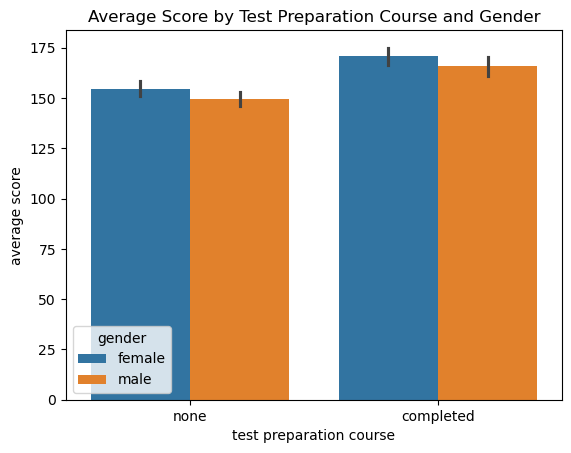

In [31]:
sns.barplot(
    x="test preparation course",
    y="average score",
    hue="gender",
    data=df
)

plt.title("Average Score by Test Preparation Course and Gender")
plt.show()

# Model Training

In [32]:
df_ml = df.drop(["math score","reading score","writing score"], axis=1)

In [33]:
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [34]:
X = df_ml.drop("result", axis=1)
y = df_ml["result"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


<Axes: >

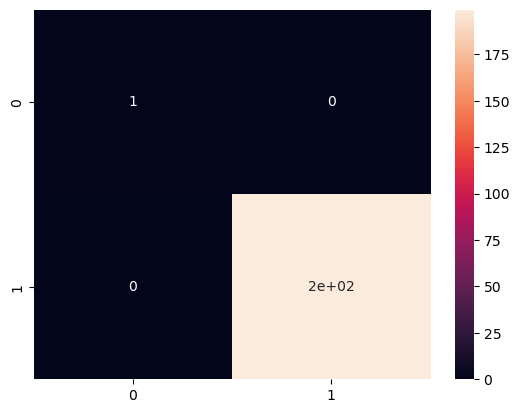

In [39]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)